# Blok B — Backbone: PPO vs DDPG

Menjawab: apakah kekalahan DDPG soal **arsitektur**, atau sebagian soal **anggaran
komputasi yang tak setara**?

Lengan MASTER murni (tanpa Modul P, tanpa attention antar-stasiun) — hanya tulang
punggung yang dibedakan. Tiga varian:

| lengan | keterangan |
|---|---|
| `master_pure_ppo_dgr` | PPO |
| `master_pure_dgr` | DDPG, anggaran baku (`updates_per_chunk=20`) |
| `master_pure_dgr_upc62` | DDPG, anggaran **disetarakan** (`updates_per_chunk=62`) |

Penyetaraan berasal dari `_hitung_langkah_gradien.py`: kedua backbone memproses jumlah
transisi lingkungan nyaris sama (rasio 1,01x) tetapi PPO menerima **3,11x lebih banyak
langkah gradien** (PPO mengulang 10 epoch/batch; DDPG dibatasi `updates_per_chunk`
terlepas dari ukuran buffer). Ukuran *replay buffer* TIDAK diubah — hanya jumlah
pembaruan gradien.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _analisis_bab5 as A

pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True, 'grid.alpha': .3})
HORIZON = '90d'

DGR = [('PPO',            'master_pure_ppo_dgr_90d_cwtfail120pen-2'),
       ('DDPG baku',      'master_pure_dgr_90d_cwtfail120pen-2'),
       ('DDPG setara',    'master_pure_dgr_90d_cwtfail120pen-2_upc62')]

# Berkas MASTER-murni memuat 4 lengan (abs/signed x dinamis/beku), berbeda dari
# berkas Hybrid yang hanya 1. Mode pelaporan baku: `signed|dinamis`.
MODE = 'signed|dinamis'

def nilai(tag, m):
    if m == 'gini_UTIL':  return A.gini_stasiun(tag, 'gini_utilisasi', HORIZON, MODE)
    if m == 'gini_ANTRE': return A.gini_stasiun(tag, 'gini_antrean',   HORIZON, MODE)
    return A.unit_stat(tag, m, HORIZON, MODE)

for n, t in DGR:
    print(f'{n:14s} n={len(nilai(t, "acc")[2])} checkpoint')

PPO            n=3 checkpoint
DDPG baku      n=3 checkpoint
DDPG setara    n=3 checkpoint


## B.1 — Hasil akhir

`rec_entropy` adalah metrik kunci di sini: nol berarti kebijakan berhenti memvariasikan
rekomendasi sama sekali.

In [2]:
M = ['gini_UTIL', 'gini_ANTRE', 'wait', 'acc', 'trust', 'rec_entropy', 'herding']
baris = []
for n, t in DGR:
    r = {'lengan': n}
    for m in M:
        r[m] = nilai(t, m)[0]
    baris.append(r)
tab = pd.DataFrame(baris).set_index('lengan')
A.ARAH_BAIK.update({'gini_UTIL': 'min', 'gini_ANTRE': 'min'})
display(A.sorot_terbaik(tab, M))

,gini_UTIL,gini_ANTRE,wait,acc,trust,rec_entropy,herding
lengan,,,,,,,
PPO,0.0583,0.1692,76.3013,0.7290,0.4065,0.0787,0.3446
DDPG baku,0.3398,0.4049,896.0176,0.8771,0.4304,0.0180,0.3859
DDPG setara,0.1922,0.2535,479.3017,0.7874,0.4278,0.0403,0.3707


In [3]:
print('NILAI PER-CHECKPOINT — di sinilah kolapsnya terlihat\n')
for m in ['rec_entropy', 'gini_UTIL', 'wait']:
    print(f'{m}')
    for n, t in DGR:
        v = nilai(t, m)[2]
        print(f'   {n:14s} {np.round(v, 4).tolist()}')
    print()
print('>> DDPG baku: entropi rekomendasi mendekati/persis NOL di 2 dari 3 checkpoint.')
print('   Kebijakan berhenti memvariasikan saran -- semua permintaan ke satu stasiun.')

NILAI PER-CHECKPOINT — di sinilah kolapsnya terlihat

rec_entropy
   PPO            [0.0784, 0.0897, 0.0679]
   DDPG baku      [0.0, 0.0539, 0.0001]
   DDPG setara    [0.109, 0.0118, 0.0001]

gini_UTIL
   PPO            [0.0356, 0.0295, 0.1098]
   DDPG baku      [0.4969, 0.0247, 0.4977]
   DDPG setara    [0.0312, 0.0559, 0.4895]

wait
   PPO            [68.8775, 70.1508, 89.8756]
   DDPG baku      [1263.6443, 134.785, 1289.6234]
   DDPG setara    [66.2629, 110.0778, 1261.5644]

>> DDPG baku: entropi rekomendasi mendekati/persis NOL di 2 dari 3 checkpoint.
   Kebijakan berhenti memvariasikan saran -- semua permintaan ke satu stasiun.


## B.2 — Apakah penyetaraan anggaran menyelamatkan DDPG?

In [4]:
baris = []
for m in ['gini_UTIL', 'wait', 'rec_entropy', 'acc', 'trust']:
    b = nilai(DGR[1][1], m)[0]; s = nilai(DGR[2][1], m)[0]; p = nilai(DGR[0][1], m)[0]
    baris.append({'metrik': m, 'DDPG baku': b, 'DDPG setara': s, 'PPO': p,
                  'perbaikan %': 100 * (s - b) / abs(b) if b else np.nan,
                  'sisa gap ke PPO %': 100 * (s - p) / abs(p) if p else np.nan})
display(pd.DataFrame(baris).set_index('metrik').round(3))

print('Anggaran setara memperbaiki DDPG SUBSTANSIAL, tetapi tidak menutup gap.')
print('Periksa per-checkpoint: apakah perbaikannya merata, atau bimodal?\n')
for n, t in DGR[1:]:
    print(f'{n:14s} gini_UTIL per-ckpt = {np.round(nilai(t, "gini_UTIL")[2], 4).tolist()}')
print()
print('>> Bimodal: sebagian checkpoint membaik, sebagian tetap gagal dgn nilai')
print('   hampir identik. Kegagalan tidak terdistribusi merata -- ia MODE, bukan derajat.')

,DDPG baku,DDPG setara,PPO,perbaikan %,sisa gap ke PPO %
metrik,,,,,
gini_UTIL,0.340,0.192,0.058,-43.435,229.801
wait,896.018,479.302,76.301,-46.508,528.170
rec_entropy,0.018,0.040,0.079,124.234,-48.789
acc,0.877,0.787,0.729,-10.224,8.008
trust,0.430,0.428,0.406,-0.620,5.239


Anggaran setara memperbaiki DDPG SUBSTANSIAL, tetapi tidak menutup gap.
Periksa per-checkpoint: apakah perbaikannya merata, atau bimodal?

DDPG baku      gini_UTIL per-ckpt = [0.4969, 0.0247, 0.4977]
DDPG setara    gini_UTIL per-ckpt = [0.0312, 0.0559, 0.4895]

>> Bimodal: sebagian checkpoint membaik, sebagian tetap gagal dgn nilai
   hampir identik. Kegagalan tidak terdistribusi merata -- ia MODE, bukan derajat.


## B.3 — Kegagalan terlokalisasi: spesialis per aliran

Uji paling tajam. Spesialis dilatih pada **satu** aliran reward saja, jadi tak ada
penyeimbangan multi-objektif yang bisa disalahkan.

- Aliran `wait` — reward **berekor tebal & tak terbatas**
- Aliran `gini` — reward terkurung, bebas ekor tebal

Bila DDPG gagal menyeluruh, ia harus kalah di **keduanya**.

In [5]:
SPEC = [
 ('wait', 'PPO',         'master_pure_ppo_specialist0_wait_90d_cwtfail120pen-2'),
 ('wait', 'DDPG baku',   'master_pure_specialist0_wait_90d_cwtfail120pen-2'),
 ('wait', 'DDPG setara', 'master_pure_specialist0_wait_90d_cwtfail120pen-2_upc62'),
 ('gini', 'PPO',         'master_pure_ppo_specialist1_gini_90d_cwtfail120pen-2'),
 ('gini', 'DDPG baku',   'master_pure_specialist1_gini_90d_cwtfail120pen-2'),
 ('gini', 'DDPG setara', 'master_pure_specialist1_gini_90d_cwtfail120pen-2_upc62')]
baris = []
for aliran, bk, t in SPEC:
    baris.append({'aliran': aliran, 'backbone': bk,
                  'gini_UTIL': nilai(t, 'gini_UTIL')[0],
                  'wait': nilai(t, 'wait')[0],
                  'rec_entropy': nilai(t, 'rec_entropy')[0],
                  'per_ckpt_gini_UTIL': np.round(nilai(t, 'gini_UTIL')[2], 4).tolist(),
                  'per_ckpt_wait': np.round(nilai(t, 'wait')[2], 1).tolist()})
spec = pd.DataFrame(baris).set_index(['aliran', 'backbone'])
display(spec.round(4))

gini_UTIL      wait  rec_entropy        per_ckpt_gini_UTIL           per_ckpt_wait
aliran backbone                                                                                       
wait   PPO             0.0524   85.0674       0.0712  [0.0917, 0.0474, 0.0179]     [113.6, 68.9, 72.8]
       DDPG baku       0.3296  885.0715       0.0775  [0.3493, 0.4402, 0.1991]  [986.5, 1149.6, 519.2]
       DDPG setara     0.2251  443.4210       0.0349  [0.3584, 0.1299, 0.1868]   [1044.6, 99.5, 186.2]
gini   PPO             0.0303   89.3017       0.0873  [0.0331, 0.0296, 0.0283]     [70.8, 95.5, 101.6]
       DDPG baku       0.1922  468.1576       0.1616  [0.0415, 0.0387, 0.4963]    [76.3, 74.9, 1253.3]
       DDPG setara     0.0479   76.0856       0.1957  [0.0469, 0.0541, 0.0427]      [74.4, 76.7, 77.2]

In [6]:
print('PERBANDINGAN PADA ALIRAN MASING-MASING (metrik yang dioptimasi spesialis itu)\n')
for aliran, m in [('gini', 'gini_UTIL'), ('wait', 'wait')]:
    print(f'spesialis {aliran} -> dinilai pada {m}:')
    sub = spec.loc[aliran]
    for bk in sub.index:
        print(f'   {bk:14s} {sub.loc[bk, m]:9.4f}')
    terbaik = sub[m].idxmin()
    print(f'   -> terbaik: {terbaik}')
    print()
print('>> Bila DDPG-setara MENGUNGGULI PPO pada aliran gini, kegagalannya BUKAN')
print('   menyeluruh -- melainkan terlokalisasi pada aliran berekor tebal (wait).')

PERBANDINGAN PADA ALIRAN MASING-MASING (metrik yang dioptimasi spesialis itu)

spesialis gini -> dinilai pada gini_UTIL:
   PPO               0.0303
   DDPG baku         0.1922
   DDPG setara       0.0479
   -> terbaik: PPO

spesialis wait -> dinilai pada wait:
   PPO              85.0674
   DDPG baku       885.0715
   DDPG setara     443.4210
   -> terbaik: PPO

>> Bila DDPG-setara MENGUNGGULI PPO pada aliran gini, kegagalannya BUKAN
   menyeluruh -- melainkan terlokalisasi pada aliran berekor tebal (wait).


## B.4 — Bukti proses: entropi kebijakan selama pelatihan

Metrik hasil menunjukkan *bahwa* DDPG kolaps; kurva pelatihan menunjukkan *kapan* dan
*bagaimana*.

Catatan: DDPG dan PPO merekam kunci berbeda — PPO punya `entropy` (entropi kebijakan
stokastik), DDPG tidak (kebijakannya deterministik; eksplorasi lewat derau `noise_std`).
Perbandingan langsung karena itu tidak mungkin; yang dibandingkan adalah `gini_util`
dan norma gradien selama pelatihan.

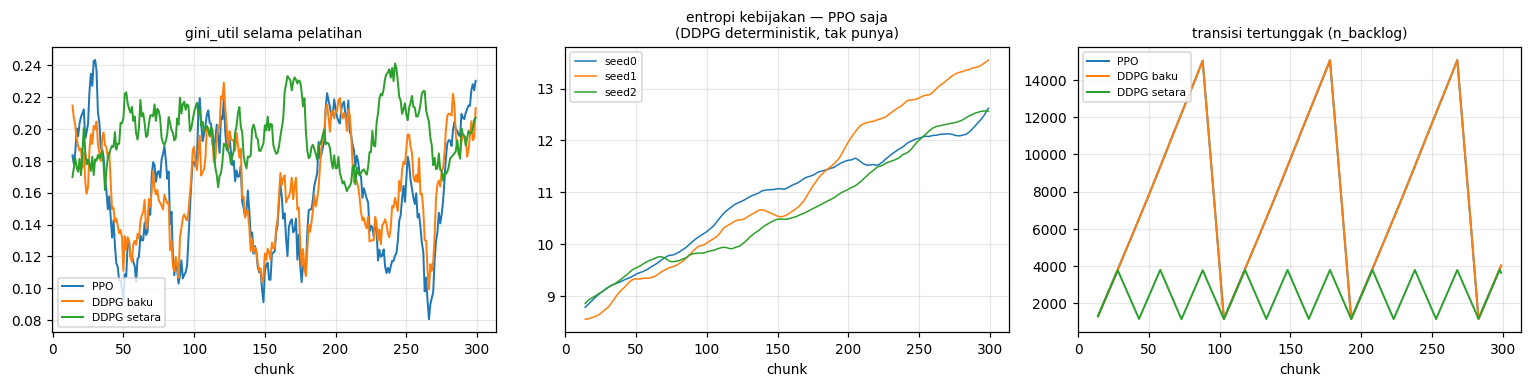

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for n, t in DGR:
    gu = A.kurva_latih(t, 'gini_util')
    axes[0].plot(gu.index, gu.mean(axis=1).rolling(15).mean(), lw=1.3, label=n)
    bl = A.kurva_latih(t, 'n_backlog')
    axes[2].plot(bl.index, bl.mean(axis=1).rolling(15).mean(), lw=1.3, label=n)
axes[0].set_title('gini_util selama pelatihan', fontsize=9); axes[0].legend(fontsize=7)
axes[0].set_xlabel('chunk')
ent = A.kurva_latih(DGR[0][1], 'entropy')
for c in ent.columns:
    axes[1].plot(ent.index, ent[c].rolling(15).mean(), lw=1, label=c)
axes[1].set_title('entropi kebijakan — PPO saja\n(DDPG deterministik, tak punya)', fontsize=9)
axes[1].legend(fontsize=7); axes[1].set_xlabel('chunk')
axes[2].set_title('transisi tertunggak (n_backlog)', fontsize=9); axes[2].set_xlabel('chunk')
axes[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

In [8]:
baris = []
for n, t in DGR:
    r = {'lengan': n}
    for k, lbl in [('gini_util', 'gini_util_akhir'), ('n_backlog', 'backlog_akhir')]:
        r[lbl] = A.kurva_latih(t, k).iloc[-50:].values.mean()
    for k in ['grad_norm', 'actor_grad']:
        try:
            r['grad_akhir'] = A.kurva_latih(t, k).iloc[-50:].values.mean(); break
        except KeyError:
            continue
    baris.append(r)
display(pd.DataFrame(baris).set_index('lengan').round(3))
print('n_backlog = transisi yang menumpuk belum terproses. Naik tajam di semua lengan')
print('-> gejala tingkat-lingkungan (beban melebihi laju layanan), bukan khas satu backbone.')

,gini_util_akhir,backlog_akhir,grad_akhir
lengan,,,
PPO,0.171,7184.013,276.842
DDPG baku,0.178,7182.640,0.014
DDPG setara,0.191,2802.267,0.397


n_backlog = transisi yang menumpuk belum terproses. Naik tajam di semua lengan
-> gejala tingkat-lingkungan (beban melebihi laju layanan), bukan khas satu backbone.


## B.5 — Bobot DGR

Pada PPO, bobot β dihitung dari gap-ratio berbasis *return* teragregasi; pada DDPG dari
bentuk asli MASTER yang bersyarat pada aksi spesialis. Keduanya menghasilkan vektor
bobot per aliran, jadi kestabilannya tetap dapat dibandingkan.

In [9]:
for n, t in DGR:
    try:
        b = A.beta_akhir(t)
        sd = b.iloc[:, 0].std(ddof=0)
        print(f'{n:14s} SD antar-seed pd bobot aliran-1 = {sd:.4f}')
        for s, row in b.iterrows():
            print(f'      seed{s}: {np.round(row.values, 3).tolist()}')
    except Exception as e:
        print(f'{n:14s} tak dapat dibaca: {e}')
    print()

PPO            SD antar-seed pd bobot aliran-1 = 0.0899
      seed0: [0.476, 0.524]
      seed1: [0.675, 0.325]
      seed2: [0.658, 0.342]

DDPG baku      SD antar-seed pd bobot aliran-1 = 0.0991
      seed0: [0.58, 0.42]
      seed1: [0.673, 0.327]
      seed2: [0.432, 0.568]

DDPG setara    SD antar-seed pd bobot aliran-1 = 0.0673
      seed0: [0.549, 0.451]
      seed1: [0.694, 0.306]
      seed2: [0.553, 0.447]



## B.6 — Ringkasan Blok B

In [10]:
print('RINGKASAN BLOK B'.center(74, '='))
gp = nilai(DGR[0][1], 'gini_UTIL')[0]; gb = nilai(DGR[1][1], 'gini_UTIL')[0]
gs = nilai(DGR[2][1], 'gini_UTIL')[0]
print(f'\ngini_UTIL  PPO={gp:.4f}  DDPG baku={gb:.4f}  DDPG setara={gs:.4f}')
ep = nilai(DGR[0][1], 'rec_entropy')[2]; eb = nilai(DGR[1][1], 'rec_entropy')[2]
print(f'rec_entropy per-ckpt  PPO={np.round(ep,4).tolist()}  DDPG baku={np.round(eb,4).tolist()}')
print()
print('KESIMPULAN yang dapat dipertanggungjawabkan:')
print('  1. DDPG baku kolaps: entropi rekomendasi ~0 pada sebagian checkpoint.')
print('  2. Anggaran gradien memang TIDAK setara (3,11x) -- konfound nyata,')
print('     dan menyetarakannya memperbaiki DDPG secara substansial.')
print('  3. TAPI kolaps bertahan secara BIMODAL: sebagian checkpoint tetap gagal')
print('     dgn nilai hampir identik -> mode kegagalan, bukan kekurangan anggaran.')
print('  4. Periksa B.3: bila DDPG unggul pada aliran gini, kegagalan TERLOKALISASI')
print('     pada aliran berekor tebal, bukan kelemahan algoritmik menyeluruh.')
print()
print('IMPLIKASI untuk IV.1.10: PPO dipilih karena menahan MODE KEGAGALAN SPESIFIK')
print('yang dipicu reward berekor tebal -- bukan karena "PPO lebih baik" secara umum.')

=============================RINGKASAN BLOK B=============================

gini_UTIL  PPO=0.0583  DDPG baku=0.3398  DDPG setara=0.1922
rec_entropy per-ckpt  PPO=[0.0784, 0.0897, 0.0679]  DDPG baku=[0.0, 0.0539, 0.0001]

KESIMPULAN yang dapat dipertanggungjawabkan:
  1. DDPG baku kolaps: entropi rekomendasi ~0 pada sebagian checkpoint.
  2. Anggaran gradien memang TIDAK setara (3,11x) -- konfound nyata,
     dan menyetarakannya memperbaiki DDPG secara substansial.
  3. TAPI kolaps bertahan secara BIMODAL: sebagian checkpoint tetap gagal
     dgn nilai hampir identik -> mode kegagalan, bukan kekurangan anggaran.
  4. Periksa B.3: bila DDPG unggul pada aliran gini, kegagalan TERLOKALISASI
     pada aliran berekor tebal, bukan kelemahan algoritmik menyeluruh.

IMPLIKASI untuk IV.1.10: PPO dipilih karena menahan MODE KEGAGALAN SPESIFIK
yang dipicu reward berekor tebal -- bukan karena "PPO lebih baik" secara umum.
